# 05 — Baseline Machine Learning Classification
## SVM + Random Forest with Oversampling

---

This notebook trains **two baseline classifiers** (SVM and Random Forest) on hand-crafted
audio features to establish Phase 1 performance benchmarks. We address the severe class
imbalance (36:1) through random oversampling in the training set.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from matplotlib.colors import ListedColormap

from src.utils import set_plot_style, FEATURES_DIR
from src.model import prepare_data, train_svm, train_rf, evaluate_model, plot_confusion_matrix

set_plot_style()
print("Baseline ML Environment Ready")

Baseline ML Environment Ready


In [2]:
# Load feature matrix
feature_path = os.path.join(FEATURES_DIR, "features.csv")
df = pd.read_csv(feature_path)
print(f"Loaded {len(df)} samples with {len(df.columns)} columns")
print(f"Classes: {sorted(df['label'].unique())}")
print(f"\nClass distribution:")
print(df['label'].value_counts().sort_index())

Loaded 2108 samples with 109 columns
Classes: ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'lonely', 'scared', 'tired']

Class distribution:
label
belly_pain    254
burping       236
cold_hot      230
discomfort    276
hungry        764
lonely         22
scared         54
tired         272
Name: count, dtype: int64


In [3]:
# Prepare data with oversampling
X_train, X_test, y_train, y_test, le, scaler, feature_names = prepare_data(df, test_size=0.2)
print(f"Training samples (after oversampling): {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {len(feature_names)}")
print(f"Classes: {list(le.classes_)}")

Training samples (after oversampling): 4888
Test samples: 422
Number of features: 106
Classes: ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'lonely', 'scared', 'tired']


In [4]:
# Train SVM
print("=" * 60)
print("Training Support Vector Machine (SVM)")
print("=" * 60)
best_svm, svm_cv_results = train_svm(X_train, y_train)

print()
print("=" * 60)
print("Training Random Forest Ensemble")
print("=" * 60)
best_rf, rf_cv_results = train_rf(X_train, y_train)

Training Support Vector Machine (SVM)
Fitting 5 folds for each of 16 candidates, totalling 80 fits



[SVM] Best Parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
[SVM] Best CV F1-score: 0.8693

Training Random Forest Ensemble
Fitting 5 folds for each of 12 candidates, totalling 60 fits



[RF] Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}
[RF] Best CV F1-score: 0.8579


In [5]:
# Evaluate SVM
print("=" * 60)
print("SVM Evaluation on Test Set")
print("=" * 60)
metrics_svm, report_svm, cm_svm = evaluate_model(best_svm, X_test, y_test, le)
print(report_svm)
print(f"SVM Accuracy: {metrics_svm['accuracy']*100:.2f}%")
print(f"SVM Macro F1: {metrics_svm['f1_macro']*100:.2f}%")

print()
print("=" * 60)
print("Random Forest Evaluation on Test Set")
print("=" * 60)
metrics_rf, report_rf, cm_rf = evaluate_model(best_rf, X_test, y_test, le)
print(report_rf)
print(f"RF Accuracy: {metrics_rf['accuracy']*100:.2f}%")
print(f"RF Macro F1: {metrics_rf['f1_macro']*100:.2f}%")

SVM Evaluation on Test Set
              precision    recall  f1-score   support

  belly_pain       0.06      0.02      0.03        51
     burping       0.00      0.00      0.00        47
    cold_hot       0.00      0.00      0.00        46
  discomfort       0.14      0.05      0.08        55
      hungry       0.28      0.61      0.38       153
      lonely       0.00      0.00      0.00         4
      scared       1.00      0.18      0.31        11
       tired       0.06      0.02      0.03        55

    accuracy                           0.24       422
   macro avg       0.19      0.11      0.10       422
weighted avg       0.16      0.24      0.16       422

SVM Accuracy: 23.70%
SVM Macro F1: 10.28%

Random Forest Evaluation on Test Set
              precision    recall  f1-score   support

  belly_pain       0.43      0.47      0.45        51
     burping       0.35      0.36      0.36        47
    cold_hot       0.17      0.11      0.13        46
  discomfort       0.08  

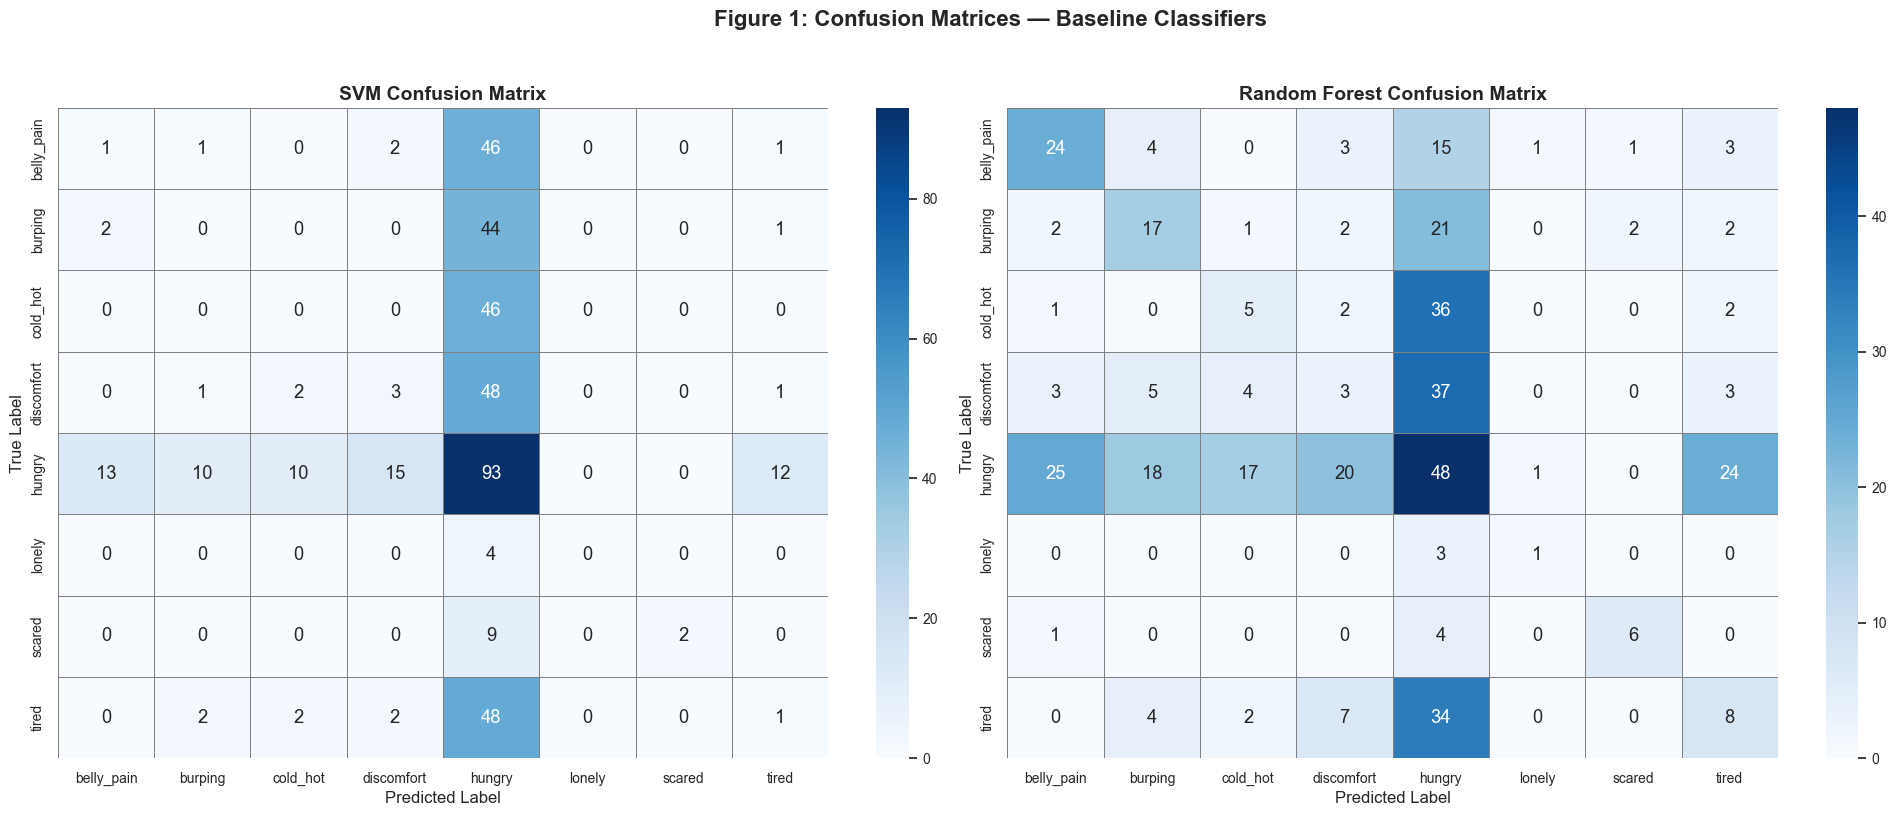

In [6]:
# ============================================================
# Figure 1: Confusion Matrices — SVM vs Random Forest
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

plot_confusion_matrix(cm_svm, le.classes_, title="SVM Confusion Matrix", ax=ax1)
plot_confusion_matrix(cm_rf, le.classes_, title="Random Forest Confusion Matrix", ax=ax2)

plt.suptitle("Figure 1: Confusion Matrices — Baseline Classifiers", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

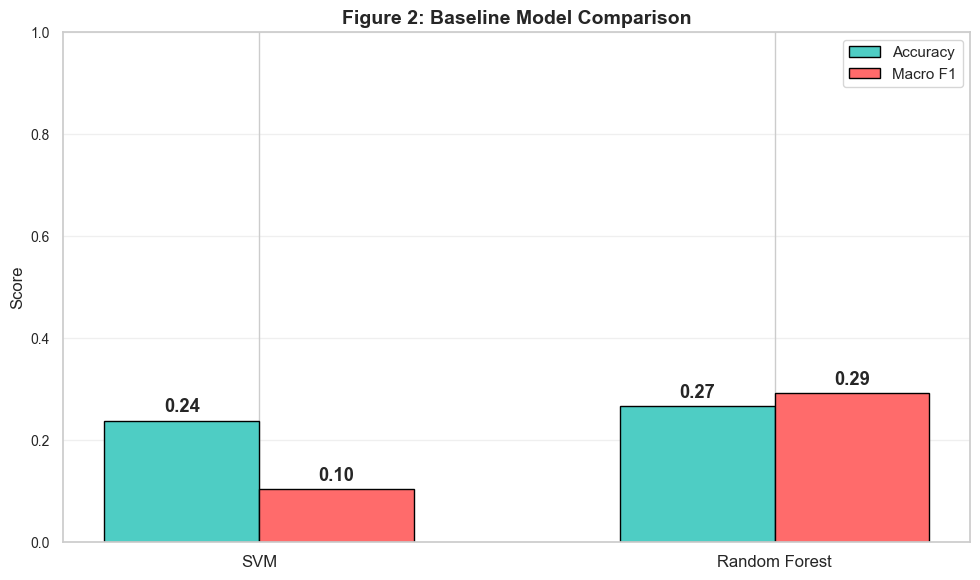

In [7]:
# ============================================================
# Figure 2: Model Comparison — Accuracy & F1
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

models = ['SVM', 'Random Forest']
accuracies = [metrics_svm['accuracy'], metrics_rf['accuracy']]
f1_scores = [metrics_svm['f1_macro'], metrics_rf['f1_macro']]

x = np.arange(len(models))
width = 0.3

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#4ECDC4', edgecolor='black')
bars2 = ax.bar(x + width/2, f1_scores, width, label='Macro F1', color='#FF6B6B', edgecolor='black')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Figure 2: Baseline Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

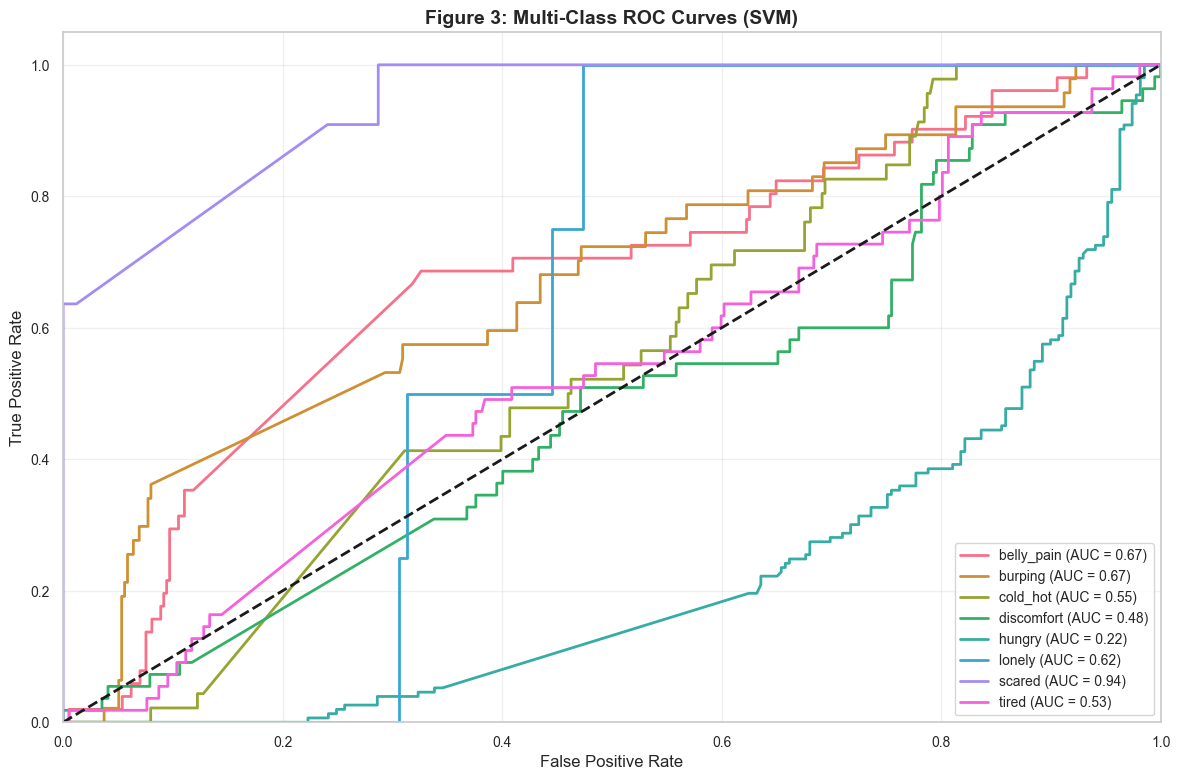

In [8]:
# ============================================================
# Figure 3: Multi-Class ROC Curves (SVM)
# ============================================================

y_score = best_svm.decision_function(X_test)
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = y_test_bin.shape[1]

fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette("husl", n_classes)
for i, color in zip(range(n_classes), colors):
    ax.plot(fpr[i], tpr[i], color=color, lw=2,
            label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.2f})")

ax.plot([0, 1], [0, 1], "k--", lw=2)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Figure 3: Multi-Class ROC Curves (SVM)", fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

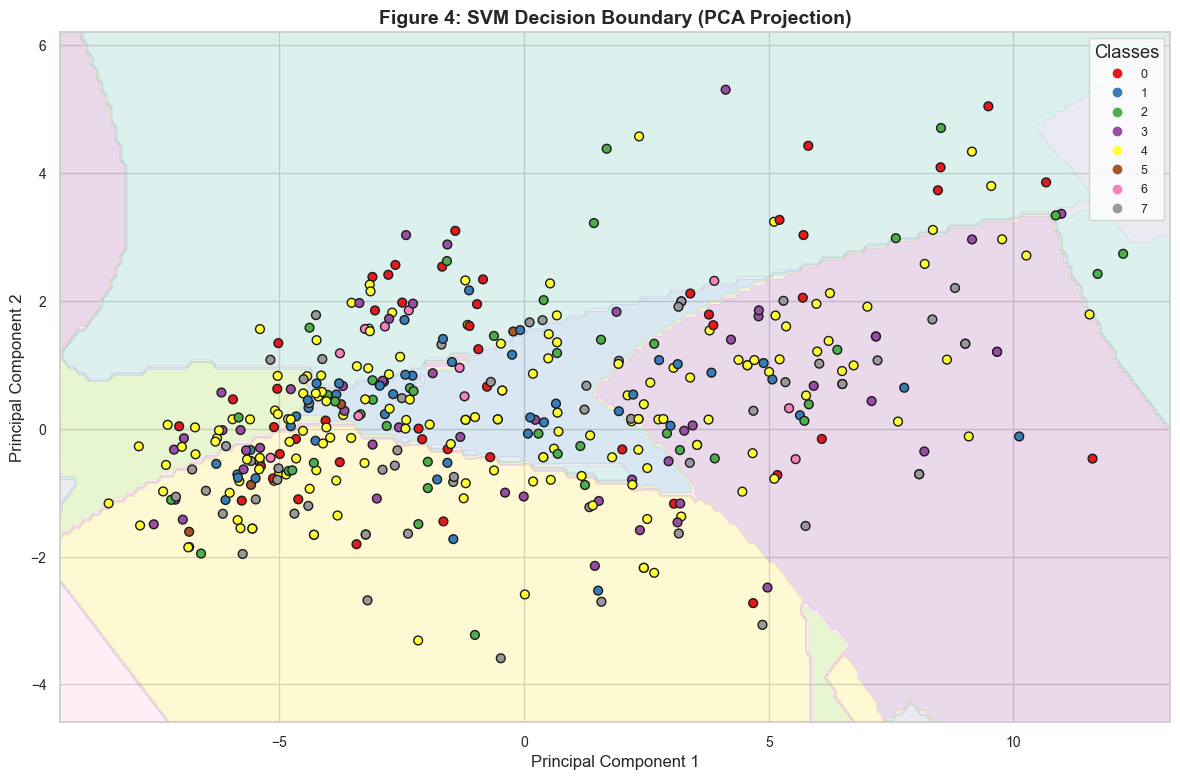


BASELINE EVALUATION COMPLETE
Best SVM Accuracy:  23.70%  |  F1: 10.28%
Best RF Accuracy:   26.54%  |  F1: 29.12%
Next: 06_dl_literature_review.ipynb


In [9]:
# ============================================================
# Figure 4: PCA Decision Boundary Visualization (SVM)
# ============================================================

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model_pca = SVC(kernel='rbf', C=100, gamma=0.001, class_weight='balanced')
model_pca.fit(X_train_pca, y_train)

x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(12, 8))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='Set3')
scatter = ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test,
                     cmap='Set1', edgecolor='k', s=40)
ax.set_title("Figure 4: SVM Decision Boundary (PCA Projection)", fontsize=14, fontweight='bold')
ax.set_xlabel("Principal Component 1", fontsize=12)
ax.set_ylabel("Principal Component 2", fontsize=12)
ax.legend(*scatter.legend_elements(), title="Classes", fontsize=9)
plt.tight_layout()
plt.show()

print()
print("=" * 60)
print("BASELINE EVALUATION COMPLETE")
print(f"Best SVM Accuracy:  {metrics_svm['accuracy']*100:.2f}%  |  F1: {metrics_svm['f1_macro']*100:.2f}%")
print(f"Best RF Accuracy:   {metrics_rf['accuracy']*100:.2f}%  |  F1: {metrics_rf['f1_macro']*100:.2f}%")
print("Next: 06_dl_literature_review.ipynb")
print("=" * 60)